# Heart Disease Severity Classification (0–4)
### University of California, Irvine — Heart Disease Dataset

**Goal:** Predict the severity level of heart disease (0 = no disease, 1–4 = increasing severity) as a multi-class classification task.

---

## Notebook Structure
| # | Section |
|---|---|
| 1 | Environment Setup & Library Installation |
| 2 | Imports & Configuration |
| 3 | Data Download & Loading |
| 4 | Feature Reference |
| 5 | Exploratory Data Analysis (EDA) |
| 6 | Train / Validation / Test Split |
| 7 | Preprocessing Pipeline (Imputation Strategy A — Simple) |
| 8 | Preprocessing Pipeline (Imputation Strategy B — KNN) |
| 9 | Baseline Model — Logistic Regression |
| 10 | Baseline Evaluation: Macro F1, QWK, Confusion Matrix |
| 11 | Cross-Validation & Summary |

---
## Environment Setup

```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap ucimlrepo scipy
```

In [2]:
# Install all required libraries

! pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap ucimlrepo scipy

---
## Imports & Global Configuration

In [3]:
# Standard Library
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Dataset Download
from ucimlrepo import fetch_ucirepo

# Scikit-learn: Data Splitting
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

# Scikit-learn: Pipelines & Transformers
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.impute        import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Scikit-learn: Models
from sklearn.linear_model  import LogisticRegression

# Scikit-learn: Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

# Global Config
SEED    = 42
CLASSES = [0, 1, 2, 3, 4]

np.random.seed(SEED)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Feature Name Lists
NUMERICAL_FEATURES   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
CATEGORICAL_FEATURES = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
ALL_FEATURES         = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

print("All imports successful.")
print(f"   Numerical features   ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}")
print(f"   Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

All imports successful.
   Numerical features   (6): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
   Categorical features (7): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


---
## Data Download & Loading

We download the Heart Disease dataset directly from the UCI ML Repository using the `ucimlrepo` package.  
- **Dataset ID:** 45  
- **Source:** https://archive.ics.uci.edu/dataset/45/heart+disease  
- **303 rows**, 13 features + 1 target  
- **Target:** 0 = no disease, 1–4 = increasing severity

In [4]:
# Download from UCI
print("Fetching Heart Disease dataset from UCI ML Repository...")
heart_disease = fetch_ucirepo(id=45)

# Extract features and target
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.iloc[:, 0].copy()
y.name = 'severity'

print(f"\nDataset loaded successfully.")
print(f"   Rows × Columns : {X.shape}")
print(f"   Target classes  : {sorted(y.unique())}")
print(f"   Total samples   : {len(X)}")

Fetching Heart Disease dataset from UCI ML Repository...

Dataset loaded successfully.
   Rows × Columns : (303, 13)
   Target classes  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   Total samples   : 303


In [5]:
# Preview features
print("First 10 rows of feature data:")
X.head(10)

First 10 rows of feature data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.300,3,0.000,6.000
1,67,1,4,160,286,0,2,108,1,1.500,2,3.000,3.000
2,67,1,4,120,229,0,2,129,1,2.600,2,2.000,7.000
3,37,1,3,130,250,0,0,187,0,3.500,3,0.000,3.000
4,41,0,2,130,204,0,2,172,0,1.400,1,0.000,3.000
5,56,1,2,120,236,0,0,178,0,0.800,1,0.000,3.000
6,62,0,4,140,268,0,2,160,0,3.600,3,2.000,3.000
7,57,0,4,120,354,0,0,163,1,0.600,1,0.000,3.000
8,63,1,4,130,254,0,2,147,0,1.400,2,1.000,7.000
9,53,1,4,140,203,1,2,155,1,3.100,3,0.000,7.000


In [6]:
# Preview target
print("Target value counts (severity 0–4):")
print(y.value_counts().sort_index().to_frame('count').assign(
    pct=lambda df: (df['count'] / len(y) * 100).round(1)
))

Target value counts (severity 0–4):
          count    pct
severity              
0           164 54.100
1            55 18.200
2            36 11.900
3            35 11.600
4            13  4.300


---
## Feature Reference

| Feature | Type | Description | Missing? |
|---------|------|-------------|----------|
| `age` | Numerical | Age in years | No |
| `sex` | Categorical | 0 = female, 1 = male | No |
| `cp` | Categorical | Chest pain type (1–4) | No |
| `trestbps` | Numerical | Resting blood pressure (mmHg) | No |
| `chol` | Numerical | Serum cholesterol (mg/dl) | No |
| `fbs` | Categorical | Fasting blood sugar > 120 mg/dl (0/1) | No |
| `restecg` | Categorical | Resting ECG results (0–2) | No |
| `thalach` | Numerical | Max heart rate achieved | No |
| `exang` | Categorical | Exercise-induced angina (0/1) | No |
| `oldpeak` | Numerical | ST depression (exercise vs rest) | No |
| `slope` | Categorical | Slope of peak exercise ST segment | No |
| `ca` | Numerical | # major vessels colored by fluoroscopy (0–3) | **Yes** |
| `thal` | Categorical | 3=normal, 6=fixed defect, 7=reversible defect | **Yes** |

In [7]:
# Data types and non-null counts
print("Data types and non-null counts:")
X.info()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [8]:
# Missing value audit
missing_df = pd.DataFrame({
    'Missing Count': X.isnull().sum(),
    'Missing %'    : (X.isnull().sum() / len(X) * 100).round(2)
})
print("Missing value summary (all features):")
print(missing_df.sort_values('Missing Count', ascending=False))

Missing value summary (all features):
          Missing Count  Missing %
ca                    4      1.320
thal                  2      0.660
cp                    0      0.000
sex                   0      0.000
age                   0      0.000
chol                  0      0.000
trestbps              0      0.000
fbs                   0      0.000
restecg               0      0.000
exang                 0      0.000
thalach               0      0.000
slope                 0      0.000
oldpeak               0      0.000


---
## Exploratory Data Analysis (EDA)

In [9]:
# Descriptive statistics for numerical features
print("Descriptive Statistics — Numerical Features:")
X[NUMERICAL_FEATURES].describe().T

Descriptive Statistics — Numerical Features:


,count,mean,std,min,25%,50%,75%,max
age,303.000,54.439,9.039,29.000,48.000,56.000,61.000,77.000
trestbps,303.000,131.690,17.600,94.000,120.000,130.000,140.000,200.000
chol,303.000,246.693,51.777,126.000,211.000,241.000,275.000,564.000
thalach,303.000,149.607,22.875,71.000,133.500,153.000,166.000,202.000
oldpeak,303.000,1.040,1.161,0.000,0.000,0.800,1.600,6.200
ca,299.000,0.672,0.937,0.000,0.000,0.000,1.000,3.000


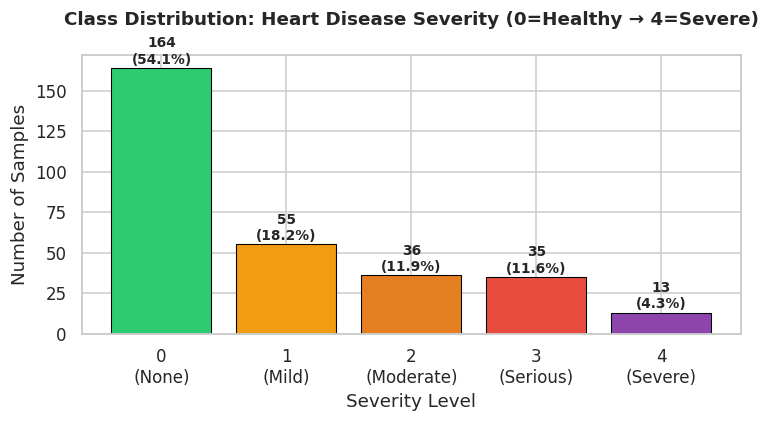


 Class imbalance note: Class 0 = 54.1% of data.
   We will use class_weight='balanced' and report Macro F1 (not accuracy).


In [10]:
# Plot 1: Class distribution
class_counts = y.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=['#2ecc71','#f39c12','#e67e22','#e74c3c','#8e44ad'],
              edgecolor='black', linewidth=0.7)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{count}\n({count/len(y)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Class Distribution: Heart Disease Severity (0=Healthy → 4=Severe)\n',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Number of Samples')
ax.set_xticks(CLASSES)
ax.set_xticklabels(['0\n(None)', '1\n(Mild)', '2\n(Moderate)', '3\n(Serious)', '4\n(Severe)'])
plt.tight_layout()
plt.show()

print(f"\n Class imbalance note: Class 0 = {class_counts[0]/len(y)*100:.1f}% of data.")
print("   We will use class_weight='balanced' and report Macro F1 (not accuracy).")

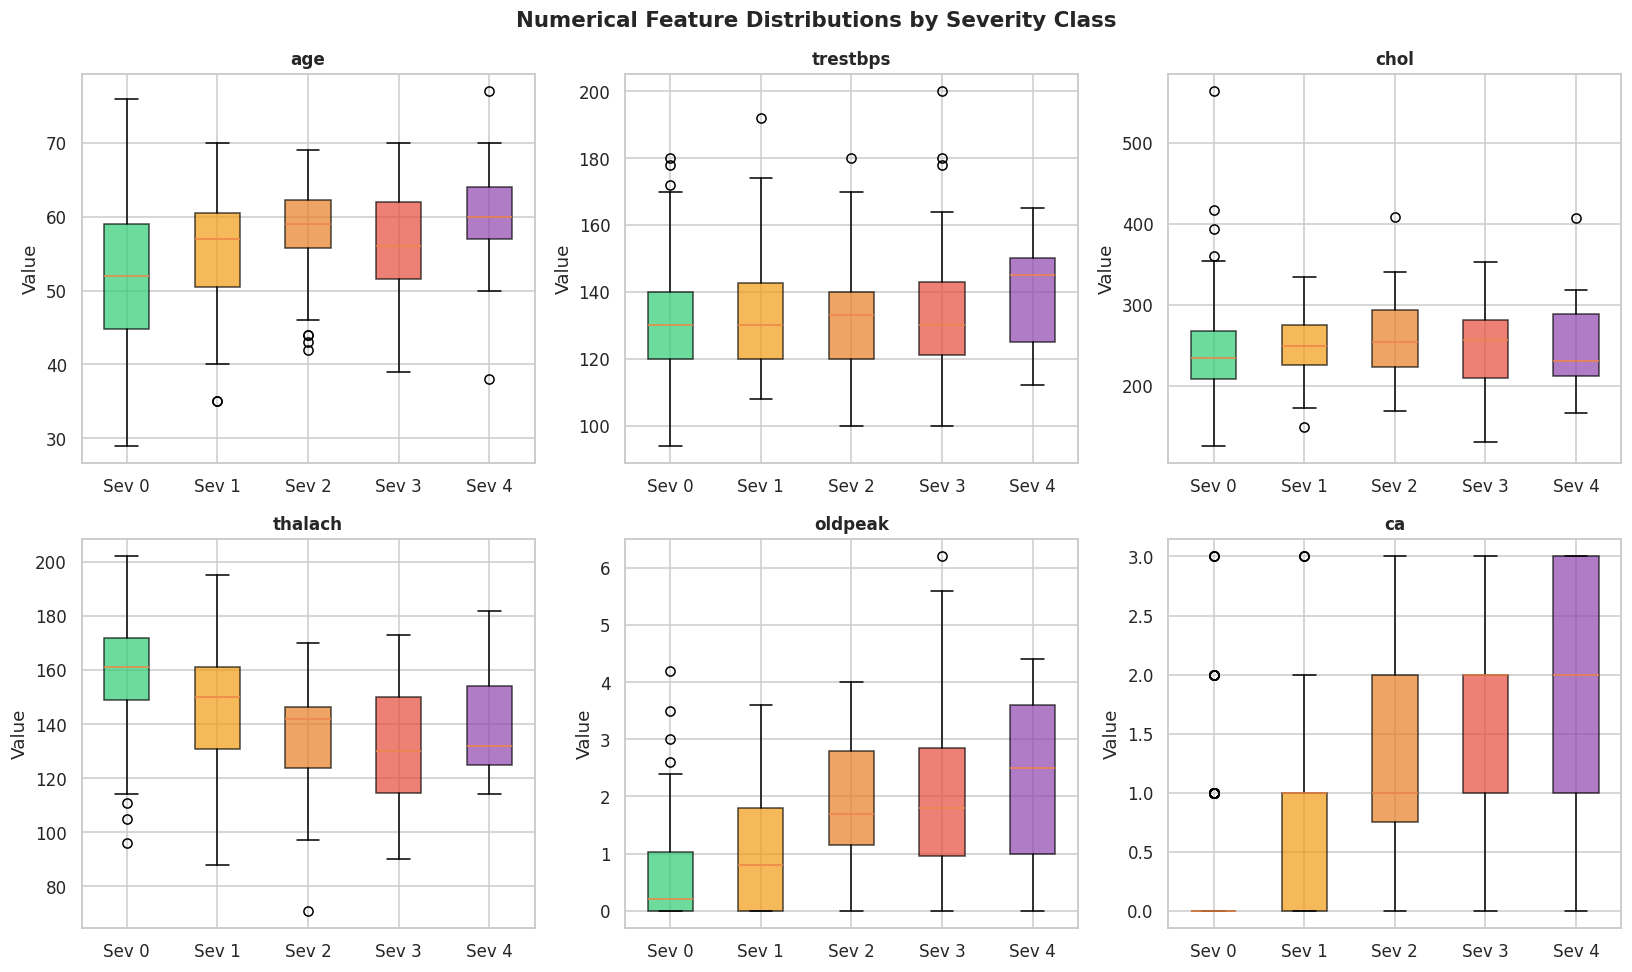

In [11]:
# Plot 2: Numerical features distribution by class
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Numerical Feature Distributions by Severity Class', fontsize=14, fontweight='bold')

palette = {0:'#2ecc71', 1:'#f39c12', 2:'#e67e22', 3:'#e74c3c', 4:'#8e44ad'}

for ax, feat in zip(axes.flat, NUMERICAL_FEATURES):
    data_list = [X.loc[y == cls, feat].dropna().values for cls in CLASSES]
    bp = ax.boxplot(data_list, labels=[f'Sev {c}' for c in CLASSES],
                    patch_artist=True, notch=False)
    for patch, cls in zip(bp['boxes'], CLASSES):
        patch.set_facecolor(list(palette.values())[cls])
        patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

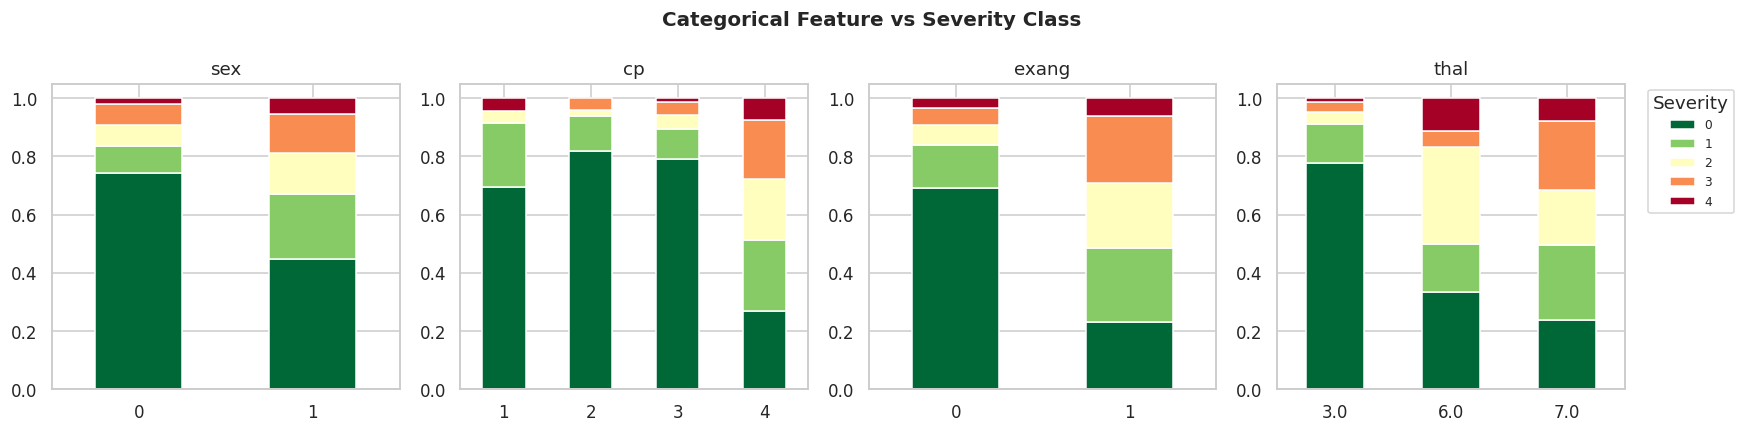

In [12]:
# Plot 3: Categorical features vs severity class
plot_cats = ['sex', 'cp', 'exang', 'thal']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Categorical Feature vs Severity Class', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, plot_cats):
    ct = pd.crosstab(X[feat], y, normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r',
            legend=(feat == plot_cats[-1]))
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    if feat == plot_cats[-1]:
        ax.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

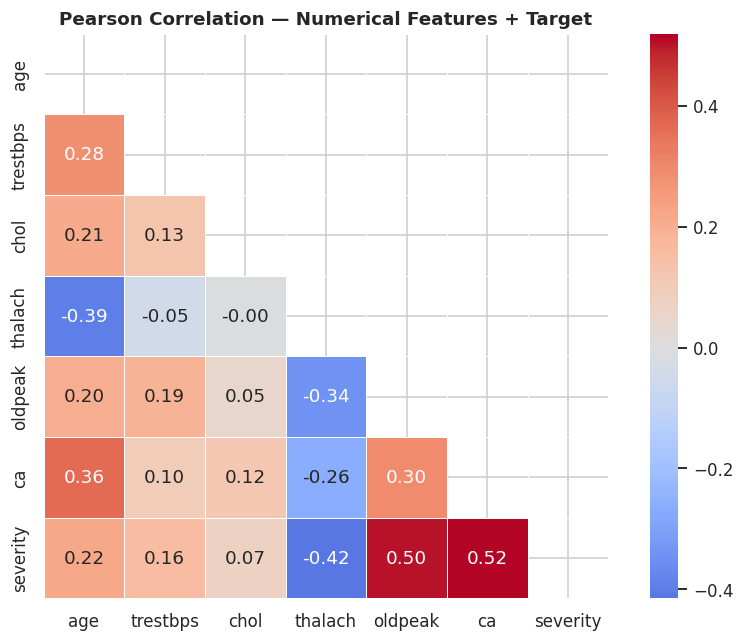


Top correlations with severity:
ca         0.519
oldpeak    0.504
thalach    0.415
age        0.223
trestbps   0.158
chol       0.071
Name: severity, dtype: float64


In [13]:
# Plot 4: Correlation heatmap
corr_data = X[NUMERICAL_FEATURES].copy()
corr_data['severity'] = y.values
corr = corr_data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Pearson Correlation — Numerical Features + Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with severity:")
print(corr['severity'].drop('severity').abs().sort_values(ascending=False))

---
## Train / Validation / Test Split

We use a **stratified 70% / 15% / 15%** split.

- `stratify=y` ensures every split has the same class proportions
- The **test set is locked away** — only used for final evaluation in later stages
- `random_state=42` ensures reproducibility

In [14]:
# Step 1: Hold out 15% as test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

# Step 2: Split remainder into train (70%) and val (15%)
# 0.176 × 85% ≈ 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.176,
    random_state=SEED,
    stratify=y_trainval
)

# Verify sizes
total = len(X)
print("Split Summary:")
print(f"  Total   : {total} samples (100%)")
print(f"  Train   : {len(X_train)} samples ({len(X_train)/total*100:.1f}%)")
print(f"  Val     : {len(X_val)} samples ({len(X_val)/total*100:.1f}%)")
print(f"  Test    : {len(X_test)} samples ({len(X_test)/total*100:.1f}%)")

# Verify stratification
print("\nClass distribution per split (proportions):")
split_check = pd.DataFrame({
    'Train'    : y_train.value_counts(normalize=True).sort_index().round(3),
    'Val'      : y_val.value_counts(normalize=True).sort_index().round(3),
    'Test'     : y_test.value_counts(normalize=True).sort_index().round(3),
    'Full Data': y.value_counts(normalize=True).sort_index().round(3)
})
print(split_check)

Split Summary:
  Total   : 303 samples (100%)
  Train   : 211 samples (69.6%)
  Val     : 46 samples (15.2%)
  Test    : 46 samples (15.2%)

Class distribution per split (proportions):
          Train   Val  Test  Full Data
severity                              
0         0.540 0.543 0.543      0.541
1         0.180 0.196 0.174      0.182
2         0.118 0.109 0.130      0.119
3         0.118 0.109 0.109      0.116
4         0.043 0.043 0.043      0.043


---
## Preprocessing Pipeline — Strategy A: Simple Imputation

- **Numerical:** `SimpleImputer(strategy='median')` + `StandardScaler`  
- **Categorical:** `SimpleImputer(strategy='most_frequent')` + `OrdinalEncoder`

> **Key rule:** The preprocessor is **fit only on `X_train`**, then `.transform()` is applied to val and test.  
> Fitting on all data would leak test information into the model — a form of data leakage.

In [15]:
# Numerical pipeline: Impute → Scale
num_pipe_A = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical pipeline: Impute → Encode
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Combine into ColumnTransformer
preprocessor_A = ColumnTransformer(transformers=[
    ('num', num_pipe_A,  NUMERICAL_FEATURES),
    ('cat', cat_pipe,    CATEGORICAL_FEATURES)
])

# Fit on TRAIN only, then transform all splits
X_train_A = preprocessor_A.fit_transform(X_train)   # fit + transform
X_val_A   = preprocessor_A.transform(X_val)          # transform only
X_test_A  = preprocessor_A.transform(X_test)         # transform only

print("Strategy A — Simple Imputation:")
print(f"  X_train_A shape : {X_train_A.shape}")
print(f"  X_val_A   shape : {X_val_A.shape}")
print(f"  X_test_A  shape : {X_test_A.shape}")
print(f"  NaNs remaining  : {np.isnan(X_train_A).sum()} (should be 0)")
print(f"  Mean of first 3 numerical features (should be ≈0): {X_train_A[:, :3].mean(axis=0).round(4)}")

Strategy A — Simple Imputation:
  X_train_A shape : (211, 13)
  X_val_A   shape : (46, 13)
  X_test_A  shape : (46, 13)
  NaNs remaining  : 0 (should be 0)
  Mean of first 3 numerical features (should be ≈0): [-0.  0.  0.]


---
## Preprocessing Pipeline — Strategy B: KNN Imputation

- **Numerical:** `KNNImputer(n_neighbors=5)` + `StandardScaler`  
- **Categorical:** `SimpleImputer(strategy='most_frequent')` + `OrdinalEncoder`

KNN imputation estimates missing values using the **5 nearest neighbors** based on Euclidean distance.  
This is more sophisticated than median imputation and can capture feature relationships — but is slower.

In [16]:
# Numerical pipeline: KNN Impute → Scale
num_pipe_B = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler())
])

# Combine into ColumnTransformer
preprocessor_B = ColumnTransformer(transformers=[
    ('num', num_pipe_B,  NUMERICAL_FEATURES),
    ('cat', cat_pipe,    CATEGORICAL_FEATURES)   # same cat pipeline as Strategy A
])

# Fit on TRAIN only
X_train_B = preprocessor_B.fit_transform(X_train)
X_val_B   = preprocessor_B.transform(X_val)
X_test_B  = preprocessor_B.transform(X_test)

print("Strategy B — KNN Imputation (k=5):")
print(f"  X_train_B shape : {X_train_B.shape}")
print(f"  X_val_B   shape : {X_val_B.shape}")
print(f"  NaNs remaining  : {np.isnan(X_train_B).sum()} (should be 0)")

# Quick comparison: imputed values for 'ca' (most missing feature)
ca_idx = NUMERICAL_FEATURES.index('ca')

# Find rows in train that had missing ca
missing_ca_mask = X_train['ca'].isnull().values
n_missing = missing_ca_mask.sum()

if n_missing > 0:
    ca_A = X_train_A[missing_ca_mask, ca_idx]
    ca_B = X_train_B[missing_ca_mask, ca_idx]
    print(f"\n  'ca' imputed values for {n_missing} missing rows:")
    print(f"    Strategy A (median) — all same: {ca_A[:5].round(3)}")
    print(f"    Strategy B (KNN)    — varied  : {ca_B[:5].round(3)}")
else:
    print("  No missing 'ca' values in training set.")

Strategy B — KNN Imputation (k=5):
  X_train_B shape : (211, 13)
  X_val_B   shape : (46, 13)
  NaNs remaining  : 0 (should be 0)

  'ca' imputed values for 1 missing rows:
    Strategy A (median) — all same: [-0.69]
    Strategy B (KNN)    — varied  : [-0.051]


---
## Baseline Model — Logistic Regression

We build a **full sklearn Pipeline** (preprocessor + classifier) so that:
- Preprocessing and modeling are encapsulated in one object
- Hyperparameter search (later) can tune both preprocessing and model parameters
- No data leakage during cross-validation

**Why Logistic Regression as baseline?**
- Fast, interpretable, well-understood
- Provides probability estimates out of the box
- Sets a meaningful lower bound for improved models to beat

In [17]:
# Build Full Pipeline: Preprocessor A + Logistic Regression
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_A),        # Strategy A: SimpleImputer + StandardScaler
    ('classifier',   LogisticRegression(
        multi_class='multinomial',            # softmax over all 5 classes
        solver='lbfgs',                       # good for multinomial
        max_iter=1000,                        # enough iterations to converge
        class_weight='balanced',              # compensate for class imbalance
        random_state=SEED
    ))
])

# Train on training set
baseline_pipeline.fit(X_train, y_train)

print("Baseline pipeline trained.")
print("\nPipeline steps:")
for step_name, step_obj in baseline_pipeline.steps:
    print(f"  [{step_name}] → {type(step_obj).__name__}")

Baseline pipeline trained.

Pipeline steps:
  [preprocessor] → ColumnTransformer
  [classifier] → LogisticRegression


In [18]:
# Generate predictions on VALIDATION set
y_val_pred  = baseline_pipeline.predict(X_val)
y_val_proba = baseline_pipeline.predict_proba(X_val)  # shape: (n_samples, 5)

print(f"Predictions generated for {len(y_val_pred)} validation samples.")
print(f"Probability array shape: {y_val_proba.shape} (5 classes)")
print(f"\nSample predictions (first 10):")
print(f"  True:      {y_val.values[:]}")
print(f"  Predicted: {y_val_pred[:]}")

Predictions generated for 46 validation samples.
Probability array shape: (46, 5) (5 classes)

Sample predictions (first 10):
  True:      [1 0 0 0 0 0 2 0 3 0 0 1 2 0 0 0 1 3 0 0 0 3 1 3 0 0 3 0 0 0 0 2 1 4 4 0 2
 1 0 1 0 1 0 2 0 1]
  Predicted: [4 0 0 0 0 0 2 3 2 1 0 0 3 0 2 0 4 3 0 0 0 2 1 3 2 1 1 0 0 0 0 4 0 3 4 1 3
 0 0 3 2 3 0 1 0 3]


---
## Baseline Evaluation

We report four metrics as required by the project spec:

| Metric | Why |
|--------|-----|
| **Macro F1** | Equal weight to all classes; handles imbalance |
| **Quadratic Weighted Kappa (QWK)** | Severity-aware: penalizes predictions far from true class |
| **Confusion Matrix** | Shows which class pairs are most confused |
| **Precision-Recall Curve** | Required for imbalanced datasets |

In [19]:
# Metric 1: Full classification report
print("=" * 62)
print(" BASELINE MODEL — CLASSIFICATION REPORT (Validation Set)")
print("=" * 62)
print(classification_report(
    y_val, y_val_pred,
    target_names=[f'Severity {i}' for i in CLASSES],
    zero_division=0
))

# Metric 2: Macro F1
macro_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
print(f"Macro-Averaged F1 Score : {macro_f1:.4f}")

# Metric 3: Quadratic Weighted Kappa (severity-aware)
qwk = cohen_kappa_score(y_val, y_val_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk:.4f}")
print()
print("QWK interpretation: 0=no agreement, 0.2=slight, 0.4=moderate,")
print("                    0.6=substantial, 0.8=almost perfect, 1.0=perfect")

 BASELINE MODEL — CLASSIFICATION REPORT (Validation Set)
              precision    recall  f1-score   support

  Severity 0       0.86      0.72      0.78        25
  Severity 1       0.17      0.11      0.13         9
  Severity 2       0.17      0.20      0.18         5
  Severity 3       0.22      0.40      0.29         5
  Severity 4       0.25      0.50      0.33         2

    accuracy                           0.50        46
   macro avg       0.33      0.39      0.34        46
weighted avg       0.55      0.50      0.52        46

Macro-Averaged F1 Score : 0.3434
Quadratic Weighted Kappa: 0.5814

QWK interpretation: 0=no agreement, 0.2=slight, 0.4=moderate,
                    0.6=substantial, 0.8=almost perfect, 1.0=perfect


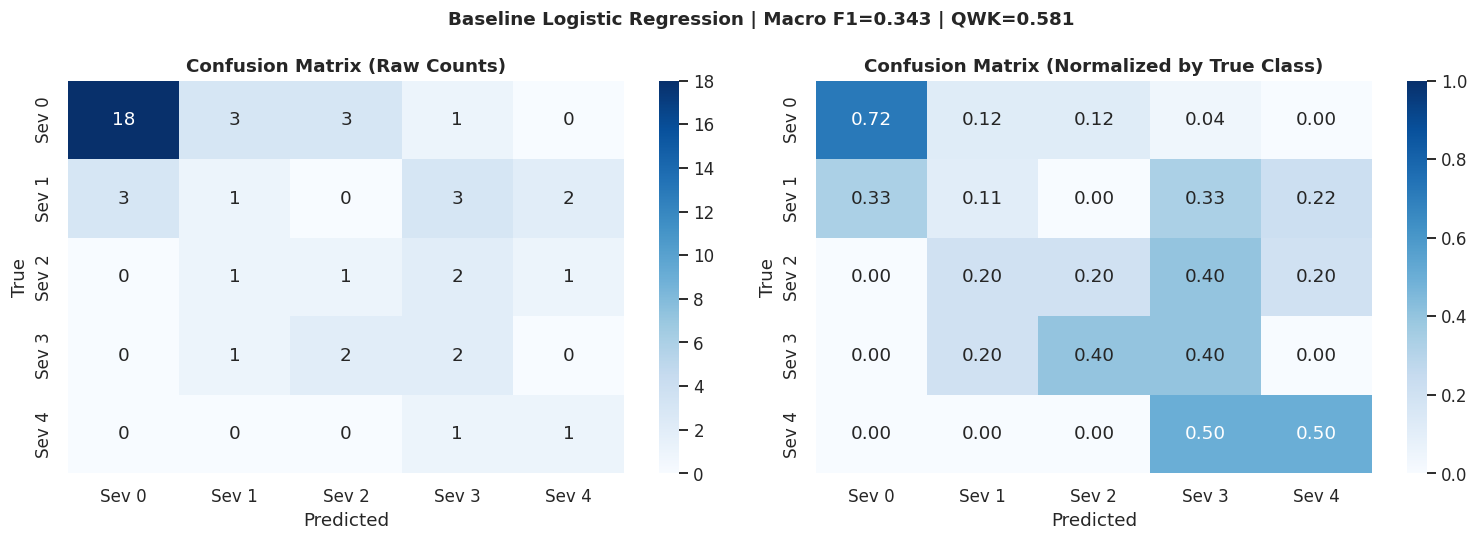


Error Analysis:
  Class 0: 18/25 correct, 7 misclassified → confused with: [(1, np.int64(3)), (2, np.int64(3)), (3, np.int64(1))]
  Class 1: 1/9 correct, 8 misclassified → confused with: [(0, np.int64(3)), (3, np.int64(3)), (4, np.int64(2))]
  Class 2: 1/5 correct, 4 misclassified → confused with: [(1, np.int64(1)), (3, np.int64(2)), (4, np.int64(1))]
  Class 3: 2/5 correct, 3 misclassified → confused with: [(1, np.int64(1)), (2, np.int64(2))]
  Class 4: 1/2 correct, 1 misclassified → confused with: [(3, np.int64(1))]


In [20]:
# Metric 4: Confusion Matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_val, y_val_pred, labels=CLASSES)
class_labels = [f'Sev {i}' for i in CLASSES]

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized by true class (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized by True Class)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

fig.suptitle(f'Baseline Logistic Regression | Macro F1={macro_f1:.3f} | QWK={qwk:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Error analysis from confusion matrix

print("\nError Analysis:")
for i in CLASSES:
    total_true = cm[i].sum()
    correct    = cm[i, i]
    errors     = total_true - correct
    print(f"  Class {i}: {correct}/{total_true} correct, {errors} misclassified", end='')
    if errors > 0:
        confused_with = [(j, cm[i,j]) for j in CLASSES if j != i and cm[i,j] > 0]
        print(f" → confused with: {confused_with}")
    else:
        print()

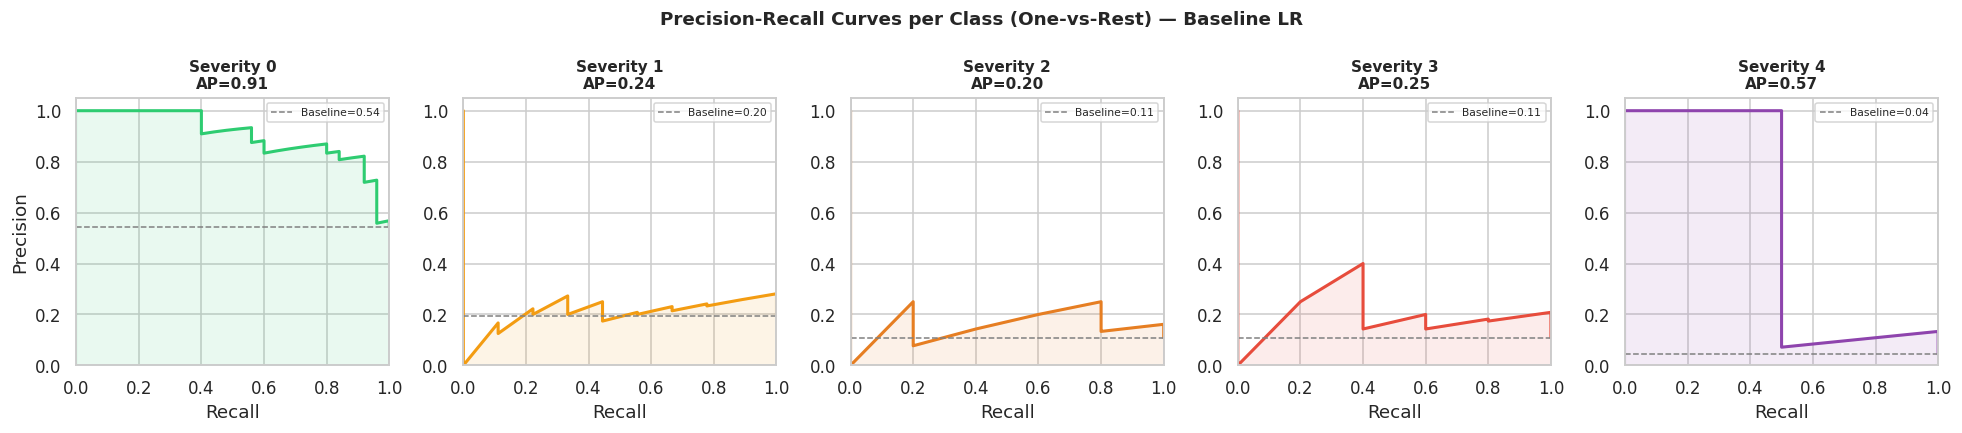

In [21]:
# Metric 5: Precision-Recall Curves (one-vs-rest per class)
y_val_bin = label_binarize(y_val, classes=CLASSES)  # shape: (n, 5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = ['#2ecc71','#f39c12','#e67e22','#e74c3c','#8e44ad']

for i, (ax, color) in enumerate(zip(axes, colors)):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_proba[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_val_proba[:, i])
    ax.plot(recall, precision, color=color, lw=2)
    ax.fill_between(recall, precision, alpha=0.1, color=color)
    ax.set_title(f'Severity {i}\nAP={ap:.2f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall')
    if i == 0:
        ax.set_ylabel('Precision')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    # Baseline = class prevalence
    baseline = (y_val == i).sum() / len(y_val)
    ax.axhline(y=baseline, color='gray', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
    ax.legend(fontsize=7)

fig.suptitle('Precision-Recall Curves per Class (One-vs-Rest) — Baseline LR',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cross-Validation & Final Summary

In [22]:
# 5-Fold Stratified Cross-Validation
# Note: using X_trainval (train+val combined) for CV, test set still locked away
print("Running 5-fold stratified cross-validation on trainval set...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_f1  = cross_val_score(baseline_pipeline, X_trainval, y_trainval,
                          cv=cv, scoring='f1_macro', n_jobs=-1)

print(f"\n  CV Macro F1 per fold : {cv_f1.round(4)}")
print(f"  Mean ± Std           : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

Running 5-fold stratified cross-validation on trainval set...

  CV Macro F1 per fold : [0.4788 0.3223 0.3302 0.3144 0.3723]
  Mean ± Std           : 0.3636 ± 0.0610


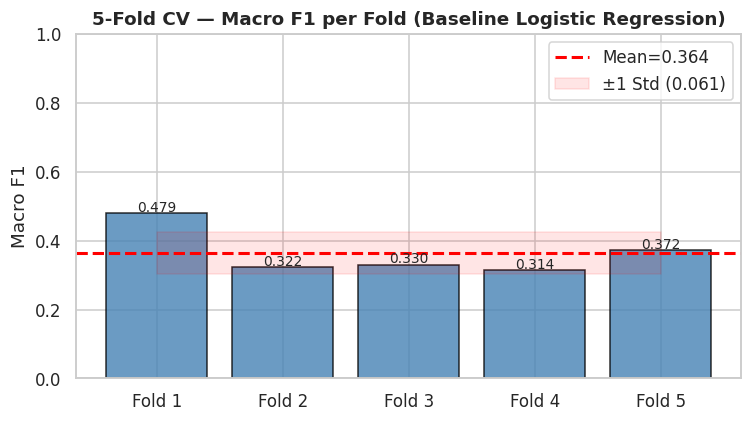

In [23]:
# CV Results plot
fig, ax = plt.subplots(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(5)]
bars  = ax.bar(folds, cv_f1, color='steelblue', alpha=0.8, edgecolor='black')
ax.axhline(cv_f1.mean(), color='red', linestyle='--', lw=2, label=f'Mean={cv_f1.mean():.3f}')
ax.fill_between(range(5), cv_f1.mean()-cv_f1.std(), cv_f1.mean()+cv_f1.std(),
                color='red', alpha=0.1, label=f'±1 Std ({cv_f1.std():.3f})')
for bar, score in zip(bars, cv_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', fontsize=9)
ax.set_title('5-Fold CV — Macro F1 per Fold (Baseline Logistic Regression)', fontweight='bold')
ax.set_ylabel('Macro F1')
ax.set_ylim([0, 1])
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Final summary
print("\n" + "="*65)
print("  BASELINE MODEL RESULTS SUMMARY")
print("="*65)

summary = pd.DataFrame({
    'Metric': [
        'Model',
        'Imputation Strategy',
        'Train Size',
        'Validation Size',
        'Test Size (locked)',
        'Macro F1 (Val)',
        'Quadratic Weighted κ (Val)',
        'CV Macro F1 (5-fold mean)',
        'CV Macro F1 (5-fold std)'
    ],
    'Value': [
        'Logistic Regression (Multinomial)',
        'SimpleImputer (Median/Mode)',
        str(len(X_train)),
        str(len(X_val)),
        str(len(X_test)),
        f'{macro_f1:.4f}',
        f'{qwk:.4f}',
        f'{cv_f1.mean():.4f}',
        f'{cv_f1.std():.4f}'
    ]
})
print(summary.to_string(index=False))


  BASELINE MODEL RESULTS SUMMARY
                    Metric                             Value
                     Model Logistic Regression (Multinomial)
       Imputation Strategy       SimpleImputer (Median/Mode)
                Train Size                               211
           Validation Size                                46
        Test Size (locked)                                46
            Macro F1 (Val)                            0.3434
Quadratic Weighted κ (Val)                            0.5814
 CV Macro F1 (5-fold mean)                            0.3636
  CV Macro F1 (5-fold std)                            0.0610
